# SMAP/AMSR-2 Data Reader and Plotter

This notebook reads extracted SMAP/AMSR-2 soil moisture data from CSV or NetCDF files and plots time series for a specified location and date range.

## Features
- Read both CSV and NetCDF files automatically based on file extension
- Find nearest point if exact coordinates are not available
- Plot soil moisture time series for specified date range
- Support for all three datasets: SPL2SMAP_S (AMSR-2), SPL2SMP, SPL2SMP_E


## Import Libraries

In [171]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')
os.chdir("/home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess")

print("Libraries imported successfully!")

Libraries imported successfully!


## Configuration

Set the file path, target point coordinates, and date range for plotting. 
Supports both CSV and NetCDF files.


In [172]:
# Configuration parameters
DATA_DIR = Path('/home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess/extracted_data') #

# Specify the data file to read (CSV or NetCDF)
# Options: 
#   - SPL2SMAP_S_AMSR2_ROI_2017.nc / .csv
#   - SPL2SMP_SMAP_L2_ROI_2017.nc / .csv
#   - SPL2SMP_E_SMAP_L2_Enhanced_ROI_2017.nc / .csv
FILE_NAME = 'SPL2SMP_E_SMAP_L2_Enhanced_ROI_2020.csv'

# Target point coordinates (lon, lat)
TARGET_LON = 75.5
TARGET_LAT = 30.5
# Target point coordinates (lon, lat)
TARGET_LON = 75.5
TARGET_LAT = 30.5

# Date range for plotting
START_DATE = '2020-01-01'
STOP_DATE = '2020-12-31'
PRECIP_FILE = "/home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv"

print(f"  Precipitation file: {PRECIP_FILE}")
print(f"  Target point: ({TARGET_LON}, {TARGET_LAT})")
print(f"  Date range: {START_DATE} to {STOP_DATE}")

print(f"  Target point: ({TARGET_LON}, {TARGET_LAT})")
print(f"  Date range: {START_DATE} to {STOP_DATE}")


  Precipitation file: /home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv
  Target point: (75.5, 30.5)
  Date range: 2020-01-01 to 2020-12-31
  Target point: (75.5, 30.5)
  Date range: 2020-01-01 to 2020-12-31


## Helper Functions

In [ ]:
def find_nearest_point(df, target_lon, target_lat):
    """
    Find the nearest point in the dataset to the target coordinates.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with 'longitude' and 'latitude' columns
    target_lon : float
        Target longitude
    target_lat : float
        Target latitude
    
    Returns:
    --------
    tuple : (nearest_lon, nearest_lat, distance_km)
    """
    # Calculate distances using Haversine approximation
    dlat = df['latitude'] - target_lat
    dlon = df['longitude'] - target_lon
    
    # Simple Euclidean distance in degrees (good for small distances)
    distances = np.sqrt(dlat**2 + dlon**2)
    
    # Find minimum distance
    min_idx = distances.idxmin()
    nearest_lon = df.loc[min_idx, 'longitude']
    nearest_lat = df.loc[min_idx, 'latitude']
    
    # Convert distance to km (rough approximation: 1 degree ≈ 111 km)
    distance_km = distances.min() * 111
    
    return nearest_lon, nearest_lat, distance_km


def read_data_to_dataframe(file_path):
    """
    Read NetCDF or CSV file and convert to pandas DataFrame.
    Automatically detects file type based on extension.
    
    Parameters:
    -----------
    file_path : Path or str
        Path to the data file (.nc or .csv)
    
    Returns:
    --------
    pandas.DataFrame : DataFrame with columns [time, latitude, longitude, soil_moisture]
    """
    file_path = Path(file_path)
    file_ext = file_path.suffix.lower()
    
    if file_ext == '.csv':
        print("Reading CSV file...")
        try:
            # Read CSV file
            df = pd.read_csv(file_path)
            
            print(f"CSV file info:")
            print(f"  Columns: {list(df.columns)}")
            print(f"  Shape: {df.shape}")
            
            # Ensure time is datetime
            if 'time' in df.columns:
                df['time'] = pd.to_datetime(df['time'])
            
            # Check for required columns
            required_cols = ['time', 'latitude', 'longitude', 'soil_moisture']
            missing_cols = [col for col in required_cols if col not in df.columns]
            
            if missing_cols:
                raise ValueError(f"Missing required columns: {missing_cols}")
            
            # Remove invalid soil moisture values
            df = df[df['soil_moisture'] >= 0]
            df = df[df['soil_moisture'] <= 1]
            df = df.dropna(subset=['soil_moisture'])
            
            # Sort by time
            df = df.sort_values('time').reset_index(drop=True)
            
            print(f"✓ CSV loaded successfully: {len(df):,} valid observations")
            
            return df
            
        except Exception as e:
            print(f"Error reading CSV file: {e}")
            raise
    
    elif file_ext == '.nc':
        print("Reading NetCDF file...")
        try:
            # Open the NetCDF file with proper decoding
            ds = xr.open_dataset(file_path, decode_times=True)
            
            print(f"Dataset info:")
            print(f"  Dimensions: {dict(ds.dims)}")
            print(f"  Data variables: {list(ds.data_vars)}")
            print(f"  Coordinates: {list(ds.coords)}")
            
            # Extract variables - they are data variables, not coordinates
            soil_moisture = ds['soil_moisture'].values
            latitude = ds['latitude'].values
            longitude = ds['longitude'].values
            
            # Time can be either coordinate or data variable
            if 'time' in ds.coords:
                time = ds['time'].values
            elif 'time' in ds.data_vars:
                time = ds['time'].values
            else:
                print("Warning: No time variable found")
                time = pd.to_datetime('1970-01-01')
            
            # Create DataFrame
            df = pd.DataFrame({
                'time': time,
                'latitude': latitude,
                'longitude': longitude,
                'soil_moisture': soil_moisture
            })
            
            # Ensure time is datetime
            df['time'] = pd.to_datetime(df['time'])
            
            # Remove invalid soil moisture values
            df = df[df['soil_moisture'] >= 0]
            df = df[df['soil_moisture'] <= 1]
            df = df.dropna(subset=['soil_moisture'])
            
            # Sort by time
            df = df.sort_values('time').reset_index(drop=True)
            
            ds.close()
            
            print(f"✓ NetCDF loaded successfully: {len(df):,} valid observations")
            
            return df
            
        except Exception as e:
            print(f"Error reading NetCDF file: {e}")
            print(f"Attempting alternative read method...")
            
            try:
                # Fallback: Try without time decoding
                ds = xr.open_dataset(file_path, decode_times=False)
                
                print(f"Fallback - Dataset info:")
                print(f"  Dimensions: {dict(ds.dims)}")
                print(f"  Data variables: {list(ds.data_vars)}")
                print(f"  Coordinates: {list(ds.coords)}")
                
                # Extract variables manually
                soil_moisture = ds['soil_moisture'].values
                latitude = ds['latitude'].values
                longitude = ds['longitude'].values
                
                # Handle time variable
                if 'time' in ds.coords:
                    time_data = ds['time'].values
                elif 'time' in ds.data_vars:
                    time_data = ds['time'].values
                else:
                    time_data = None
                
                if time_data is not None:
                    # Check if it's numeric (seconds since epoch)
                    if np.issubdtype(time_data.dtype, np.number):
                        time_vals = pd.to_datetime(time_data, unit='s')
                    else:
                        # Try to decode as string
                        try:
                            time_vals = pd.to_datetime(time_data.astype(str))
                        except:
                            time_vals = pd.to_datetime('1970-01-01')
                else:
                    time_vals = pd.to_datetime('1970-01-01')
                
                # Create DataFrame
                df = pd.DataFrame({
                    'time': time_vals if hasattr(time_vals, '__len__') else [time_vals] * len(soil_moisture),
                    'latitude': latitude,
                    'longitude': longitude,
                    'soil_moisture': soil_moisture
                })
                
                # Remove invalid soil moisture values
                df = df[df['soil_moisture'] >= 0]
                df = df[df['soil_moisture'] <= 1]
                df = df.dropna(subset=['soil_moisture'])
                
                # Sort by time
                df = df.sort_values('time').reset_index(drop=True)
                
                ds.close()
                
                print(f"✓ NetCDF loaded successfully (fallback): {len(df):,} valid observations")
                
                return df
                
            except Exception as e2:
                print(f"Final error reading file: {e2}")
                raise
    
    else:
        raise ValueError(f"Unsupported file format: {file_ext}. Only .nc and .csv files are supported.")


def filter_by_date_range(df, start_date, stop_date):
    """
    Filter DataFrame by date range.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with 'time' column
    start_date : str
        Start date in 'YYYY-MM-DD' format
    stop_date : str
        Stop date in 'YYYY-MM-DD' format
    
    Returns:
    --------
    pandas.DataFrame : Filtered DataFrame
    """
    start = pd.to_datetime(start_date)
    stop = pd.to_datetime(stop_date)
    
    mask = (df['time'] >= start) & (df['time'] <= stop)
    return df[mask].copy()


def get_point_time_series(df, target_lon, target_lat, tolerance=0.01):
    """
    Extract time series for a specific point or nearest point.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with soil moisture data
    target_lon : float
        Target longitude
    target_lat : float
        Target latitude
    tolerance : float
        Tolerance for exact match in degrees (default: 0.01)
    
    Returns:
    --------
    pandas.DataFrame : Time series for the point
    dict : Metadata about the point
    """
    # Try exact match first
    mask = (np.abs(df['longitude'] - target_lon) < tolerance) & \
           (np.abs(df['latitude'] - target_lat) < tolerance)
    
    point_df = df[mask].copy()
    
    if len(point_df) > 0:
        # Exact match found
        actual_lon = point_df['longitude'].iloc[0]
        actual_lat = point_df['latitude'].iloc[0]
        distance_km = 0.0
        match_type = 'exact'
    else:
        # No exact match, find nearest point
        nearest_lon, nearest_lat, distance_km = find_nearest_point(df, target_lon, target_lat)
        
        # Get all data for nearest point
        mask = (df['longitude'] == nearest_lon) & (df['latitude'] == nearest_lat)
        point_df = df[mask].copy()
        
        actual_lon = nearest_lon
        actual_lat = nearest_lat
        match_type = 'nearest'
    
    metadata = {
        'target_lon': target_lon,
        'target_lat': target_lat,
        'actual_lon': actual_lon,
        'actual_lat': actual_lat,
        'distance_km': distance_km,
        'match_type': match_type,
        'num_observations': len(point_df)
    }
    
    return point_df, metadata
def read_precipitation_data(file_path, target_lon, target_lat):
    """
    Read precipitation data from IMERG CSV file and extract time series for target point.
    """
    print(f"\nReading precipitation data from: {file_path}")
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Parse time column (format: DD-MM-YYYY HH:MM)
    df['time'] = pd.to_datetime(df['time'], format='%d-%m-%Y %H:%M')
    
    print(f"Precipitation data loaded:")
    print(f"  Total observations: {len(df):,}")
    print(f"  Date range: {df['time'].min()} to {df['time'].max()}")
    print(f"  Unique locations: {df[['longitude', 'latitude']].drop_duplicates().shape[0]:,}")
    
    # Find nearest point to target coordinates
    dlat = df['latitude'] - target_lat
    dlon = df['longitude'] - target_lon
    distances = np.sqrt(dlat**2 + dlon**2)
    min_idx = distances.idxmin()
    nearest_lon = df.loc[min_idx, 'longitude']
    nearest_lat = df.loc[min_idx, 'latitude']
    distance_km = distances.min() * 111
    
    # Extract data for the nearest point
    mask = (df['longitude'] == nearest_lon) & (df['latitude'] == nearest_lat)
    precip_df = df[mask].copy()
    
    # Aggregate to daily (sum precipitation)
    precip_df['date'] = precip_df['time'].dt.date
    precip_daily = precip_df.groupby('date').agg({
        'precipitation': 'sum',
        'time': 'first'
    }).reset_index(drop=True)
    precip_daily['time'] = pd.to_datetime(precip_daily['time'])
    
    print(f"\nPrecipitation point selected:")
    print(f"  Target: ({target_lon:.4f}, {target_lat:.4f})")
    print(f"  Actual: ({nearest_lon:.4f}, {nearest_lat:.4f})")
    print(f"  Distance: {distance_km:.2f} km")
    print(f"  Daily observations: {len(precip_daily):,}")
    
    metadata = {
        'target_lon': target_lon,
        'target_lat': target_lat,
        'actual_lon': nearest_lon,
        'actual_lat': nearest_lat,
        'distance_km': distance_km,
        'num_observations': len(precip_daily)
    }
    
    return precip_daily, metadata



print("Helper functions defined successfully!")


Helper functions defined successfully!


## Read Data File (CSV or NetCDF)


In [174]:
# Read the data file (CSV or NetCDF)
file_path = DATA_DIR / FILE_NAME

print(f"Reading file: {file_path}")
print(f"File exists: {file_path.exists()}\n")

if not file_path.exists():
    print(f"ERROR: File not found: {file_path}")
    print(f"\nAvailable files in {DATA_DIR}:")
    for f in sorted(DATA_DIR.glob('*')):
        if f.suffix.lower() in ['.nc', '.csv']:
            print(f"  - {f.name}")
else:
    # Read data (automatically detects CSV or NetCDF)
    df_full = read_data_to_dataframe(file_path)
    
    print(f"\nData loaded successfully!")
    print(f"Total observations: {len(df_full):,}")
    print(f"Date range: {df_full['time'].min()} to {df_full['time'].max()}")
    print(f"Longitude range: {df_full['longitude'].min():.4f} to {df_full['longitude'].max():.4f}")
    print(f"Latitude range: {df_full['latitude'].min():.4f} to {df_full['latitude'].max():.4f}")
    print(f"Soil moisture range: {df_full['soil_moisture'].min():.4f} to {df_full['soil_moisture'].max():.4f}")
    print(f"\nUnique locations: {df_full[['longitude', 'latitude']].drop_duplicates().shape[0]:,}")


Reading file: /home/intern1/my_data/sm2rain-irrigation/NASA SMAP earthaccess/extracted_data/SPL2SMP_E_SMAP_L2_Enhanced_ROI_2020.csv
File exists: True

Reading CSV file...
CSV file info:
  Columns: ['latitude', 'longitude', 'soil_moisture', 'time']
  Shape: (45795, 4)
✓ CSV loaded successfully: 45,795 valid observations

Data loaded successfully!
Total observations: 45,795
Date range: 2020-01-01 12:08:39 to 2020-12-31 11:54:28
Longitude range: 75.0156 to 75.9492
Latitude range: 30.0269 to 30.9251
Soil moisture range: 0.0200 to 0.4346

Unique locations: 132


## Extract Point Time Series

In [175]:
# Get time series for the target point (or nearest point)
point_df, metadata = get_point_time_series(df_full, TARGET_LON, TARGET_LAT)

print("Point Selection Results:")
print("=" * 50)
print(f"Target coordinates: ({metadata['target_lon']}, {metadata['target_lat']})")
print(f"Actual coordinates: ({metadata['actual_lon']:.4f}, {metadata['actual_lat']:.4f})")
print(f"Match type: {metadata['match_type']}")
if metadata['distance_km'] > 0:
    print(f"Distance from target: {metadata['distance_km']:.2f} km")
print(f"Total observations for this point: {metadata['num_observations']:,}")
print("=" * 50)

Point Selection Results:
Target coordinates: (75.5, 30.5)
Actual coordinates: (75.4824, 30.5158)
Match type: nearest
Distance from target: 2.63 km
Total observations for this point: 348


## Load Precipitation Data

In [176]:
# Load precipitation data for the same target point
if PRECIP_FILE :
    precip_df, precip_metadata = read_precipitation_data(PRECIP_FILE, TARGET_LON, TARGET_LAT)
else:
    print(f"WARNING: Precipitation file not found: {PRECIP_FILE}")
    precip_df = None
    precip_metadata = None


Reading precipitation data from: /home/intern1/my_data/sm2rain-irrigation/IMERG_ROI1_2020.csv


Precipitation data loaded:
  Total observations: 876,000
  Date range: 2020-01-01 00:00:00 to 2020-12-30 23:00:00
  Unique locations: 100

Precipitation point selected:
  Target: (75.5000, 30.5000)
  Actual: (75.5500, 30.4500)
  Distance: 7.85 km
  Daily observations: 365


## Filter by Date Range

In [177]:
# Filter soil moisture data by date range
df_filtered = filter_by_date_range(point_df, START_DATE, STOP_DATE)

print(f"Soil Moisture Date Range Filter:")
print(f"  Requested: {START_DATE} to {STOP_DATE}")
print(f"  Observations in range: {len(df_filtered):,}")

if len(df_filtered) > 0:
    print(f"  Actual date range: {df_filtered['time'].min()} to {df_filtered['time'].max()}")
    print(f"  Soil moisture range: {df_filtered['soil_moisture'].min():.4f} to {df_filtered['soil_moisture'].max():.4f}")
    print(f"  Mean soil moisture: {df_filtered['soil_moisture'].mean():.4f} cm³/cm³")
else:
    print("  WARNING: No data found in the specified date range!")

# Filter precipitation data by date range
if precip_df is not None:
    precip_filtered = filter_by_date_range(precip_df, START_DATE, STOP_DATE)
    print(f"\nPrecipitation Date Range Filter:")
    print(f"  Observations in range: {len(precip_filtered):,}")
    if len(precip_filtered) > 0:
        print(f"  Precipitation range: {precip_filtered['precipitation'].min():.4f} to {precip_filtered['precipitation'].max():.4f} mm/day")
        print(f"  Mean precipitation: {precip_filtered['precipitation'].mean():.4f} mm/day")
        print(f"  Total precipitation: {precip_filtered['precipitation'].sum():.2f} mm")
else:
    precip_filtered = None

Soil Moisture Date Range Filter:
  Requested: 2020-01-01 to 2020-12-31
  Observations in range: 346
  Actual date range: 2020-01-01 12:08:39 to 2020-12-30 00:37:35
  Soil moisture range: 0.0535 to 0.4332
  Mean soil moisture: 0.2518 cm³/cm³


TypeError: string indices must be integers, not 'str'

## Plot Time Series with Precipitation

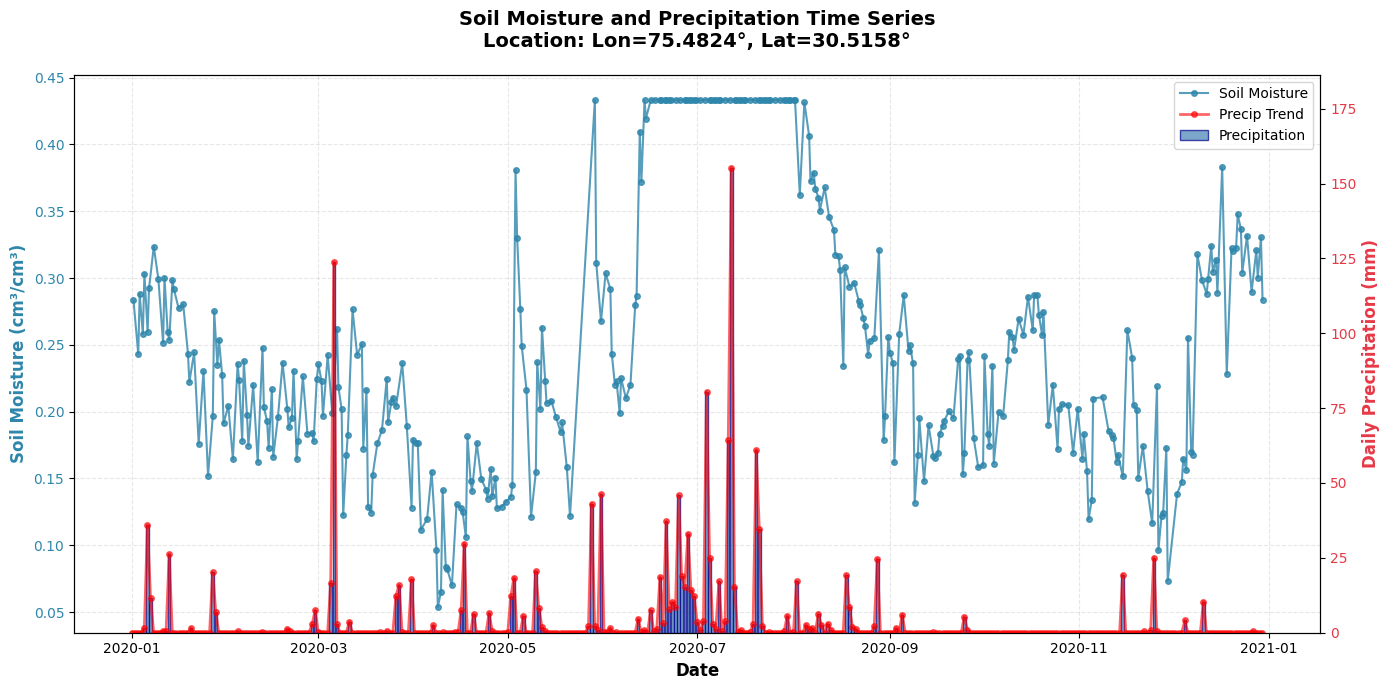


Plot generated successfully!
Soil moisture data points plotted: 346
Precipitation data points plotted: 365


In [ ]:
# Create the time series plot with dual y-axes
if len(df_filtered) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # Plot soil moisture on primary y-axis
    color_sm = '#2E86AB'
    ax1.plot(df_filtered['time'], df_filtered['soil_moisture'], 
            marker='o', markersize=4, linewidth=1.5, 
            color=color_sm, alpha=0.8, label='Soil Moisture')
    
    # Add mean line for soil moisture
    mean_sm = df_filtered['soil_moisture'].mean()
    # ax1.axhline(y=mean_sm, color='red', linestyle='--', 
    #            linewidth=2, alpha=0.7, label=f'Mean SM: {mean_sm:.4f} cm³/cm³')
    
    # Formatting for primary y-axis
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Soil Moisture (cm³/cm³)', fontsize=12, fontweight='bold', color=color_sm)
    ax1.tick_params(axis='y', labelcolor=color_sm)
    
    # Create secondary y-axis for precipitation
    if precip_filtered is not None and len(precip_filtered) > 0:
        ax2 = ax1.twinx()
        color_precip = '#E63946'
        
        # Plot precipitation as bars
        ax2.bar(precip_filtered['time'], precip_filtered['precipitation'], 
                color='steelblue', edgecolor='darkblue', alpha=0.7, label='Precipitation')
        
        # Plot precipitation trend line
        ax2.plot(precip_filtered['time'], precip_filtered['precipitation'],
                color='red', marker='o', linewidth=2, markersize=4, alpha=0.6, label='Precip Trend')
        
        # Formatting for secondary y-axis
        ax2.set_ylabel('Daily Precipitation (mm)', fontsize=12, fontweight='bold', color=color_precip)
        ax2.tick_params(axis='y', labelcolor=color_precip)
        
        # Set precipitation axis limit
        ax2.set_ylim(0, precip_filtered['precipitation'].max() * 1.2)
        
        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')
    else:
        ax1.legend(fontsize=10, loc='best')
    
    # Create title with point information
    title = "Soil Moisture and Precipitation Time Series\n"
    title += f'Location: Lon={metadata["actual_lon"]:.4f}°, Lat={metadata["actual_lat"]:.4f}°'
    ax1.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Grid
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig("SPL2SMP_with_precipitation.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot generated successfully!")
    print(f"Soil moisture data points plotted: {len(df_filtered):,}")
    if precip_filtered is not None:
        print(f"Precipitation data points plotted: {len(precip_filtered):,}")
else:
    print("Cannot create plot: No data in the specified date range.")

## Data Summary Statistics

In [ ]:
# Display summary statistics
if len(df_filtered) > 0:
    print("Summary Statistics for Filtered Data:")
    print("=" * 60)
    print(df_filtered['soil_moisture'].describe())
    print("=" * 60)
    
    # Additional statistics
    print(f"\nAdditional Statistics:")
    print(f"  Median: {df_filtered['soil_moisture'].median():.4f} cm³/cm³")
    print(f"  Variance: {df_filtered['soil_moisture'].var():.6f}")
    print(f"  Coefficient of Variation: {(df_filtered['soil_moisture'].std() / df_filtered['soil_moisture'].mean() * 100):.2f}%")
    
    # Display first few rows
    print(f"\nFirst 10 observations:")
    print(df_filtered[['time', 'soil_moisture']].head(10).to_string(index=False))
else:
    print("No data available for statistics.")

Summary Statistics for Filtered Data:
count    346.000000
mean       0.251832
std        0.098994
min        0.053512
25%        0.176941
50%        0.235225
75%        0.303997
max        0.433166
Name: soil_moisture, dtype: float64

Additional Statistics:
  Median: 0.2352 cm³/cm³
  Variance: 0.009800
  Coefficient of Variation: 39.31%

First 10 observations:
               time  soil_moisture
2020-01-01 12:08:39       0.283266
2020-01-03 01:04:07       0.243063
2020-01-03 11:44:04       0.288158
2020-01-04 12:21:01       0.257888
2020-01-05 00:39:31       0.303349
2020-01-06 01:16:24       0.259498
2020-01-06 11:56:25       0.292193
2020-01-08 00:51:48       0.323516
2020-01-09 12:08:46       0.299473
2020-01-11 01:04:09       0.251386


## Usage Instructions

To use this notebook:

1. **Modify Configuration Cell** (Cell 4):
   - Change `FILE_NAME` to the desired data file (CSV or NetCDF)
   - Set `TARGET_LON` and `TARGET_LAT` to your coordinates of interest
   - Adjust `START_DATE` and `STOP_DATE` for the desired time range

2. **Run All Cells**: Execute cells in order from top to bottom

3. **Available Files** in extracted_data directory:
   - `SPL2SMAP_S_AMSR2_ROI_YYYY.csv/.nc` - AMSR-2 data
   - `SPL2SMP_SMAP_L2_ROI_YYYY.csv/.nc` - SMAP L2 data
   - `SPL2SMP_E_SMAP_L2_Enhanced_ROI_YYYY.csv/.nc` - SMAP L2 Enhanced data

4. **File Format Support**:
   - **CSV files**: Standard comma-separated values with columns: time, latitude, longitude, soil_moisture
   - **NetCDF files**: CF-compliant NetCDF4 format with variables: soil_moisture, latitude, longitude, time
   - The reader automatically detects the file type based on the file extension

5. **Data Structure**:
   - All files contain: time, latitude, longitude, soil_moisture
   - Coordinates: Individual observations (not gridded)
   - Time format: datetime objects
